In [1]:
from google.colab import files
uploaded = files.upload()

# Load the uploaded file into a Pandas DataFrame
import pandas as pd
import io
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
df.head()

Saving Social_media_impact_on_life.csv to Social_media_impact_on_life.csv


,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


In [12]:
import pandas as pd
import numpy as np

# 1. Drop complete duplicate rows if any exist
initial_rows = len(df)
df = df.drop_duplicates()
duplicates_removed = initial_rows - len(df)

# 2. Standardize string columns (strip whitespace, ensure proper casing)
string_cols = ['Gender', 'Academic_Level', 'Primary_Platform', 'Device_Type', 'Social_Comparison_Frequency', 'Overall_Impact']
for col in string_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# 3. Handle Missing Values
# Fill numeric columns with median values
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# 4. Correct Data Types
if 'Late_Night_Usage' in df.columns:
    df['Late_Night_Usage'] = df['Late_Night_Usage'].astype(bool)

if 'Age' in df.columns:
    df['Age'] = df['Age'].astype(int)

# 5. Cap bounded numeric variables (ensure scores & metrics stay within realistic ranges)
if 'Academic_Performance_GPA' in df.columns:
    df['Academic_Performance_GPA'] = df['Academic_Performance_GPA'].clip(0.0, 4.0)

if 'Sleep_Quality_Score' in df.columns:
    df['Sleep_Quality_Score'] = df['Sleep_Quality_Score'].clip(1, 5)

# Output Summary Audit
print("=== DATA CLEANING SUMMARY ===")
print(f"Total rows processed: {len(df)}")
print(f"Duplicate rows removed: {duplicates_removed}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print("\nCleaned Data Info:")
df.info()

=== DATA CLEANING SUMMARY ===
Total rows processed: 4500
Duplicate rows removed: 0
Remaining missing values: 0

Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   object 
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   object 
 3   Academic_Level               4500 non-null   object 
 4   Primary_Platform             4500 non-null   object 
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   object 
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Soc

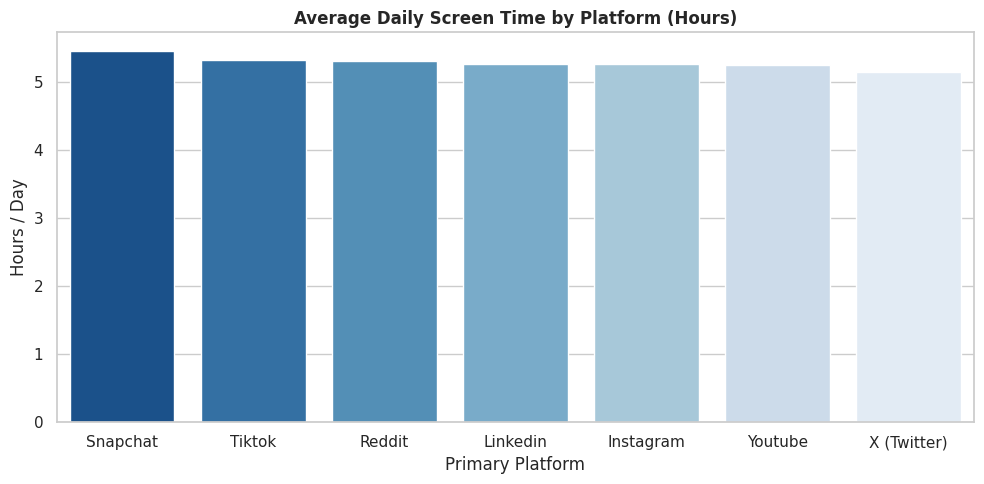

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Group and calculate average usage per platform
platform_metrics = df.groupby('Primary_Platform')['Daily_Usage_Hours'].mean().reset_index().sort_values(by='Daily_Usage_Hours', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=platform_metrics,
    x='Primary_Platform',
    y='Daily_Usage_Hours',
    hue='Primary_Platform',
    palette='Blues_r',
    legend=False
)
plt.title('Average Daily Screen Time by Platform (Hours)', fontsize=12, fontweight='bold')
plt.xlabel('Primary Platform')
plt.ylabel('Hours / Day')
plt.tight_layout()
plt.show()

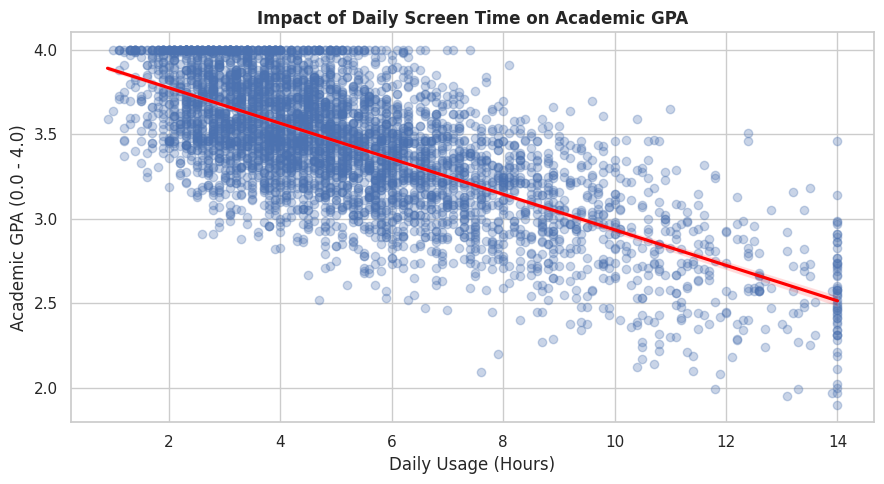

In [14]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df,
    x='Daily_Usage_Hours',
    y='Academic_Performance_GPA',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('Impact of Daily Screen Time on Academic GPA', fontsize=12, fontweight='bold')
plt.xlabel('Daily Usage (Hours)')
plt.ylabel('Academic GPA (0.0 - 4.0)')
plt.tight_layout()
plt.show()

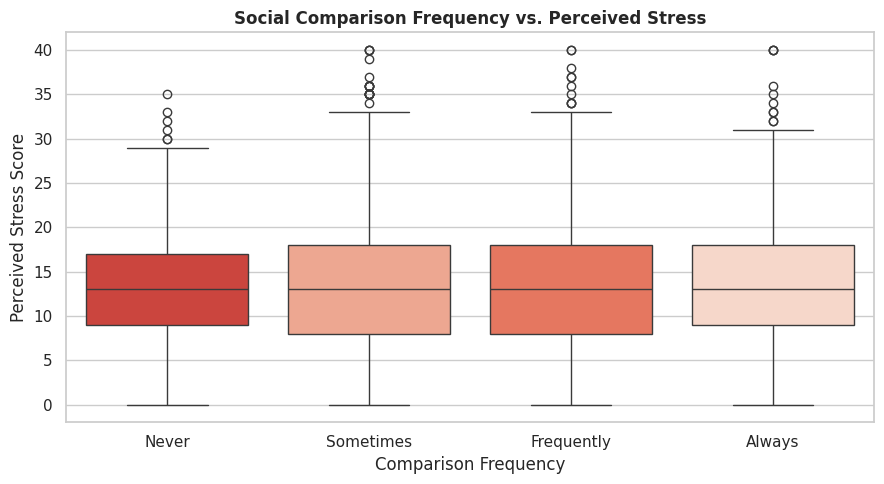

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='Social_Comparison_Frequency',
    y='Perceived_Stress_Score',
    hue='Social_Comparison_Frequency',
    palette='Reds',
    order=['Never', 'Sometimes', 'Frequently', 'Always'],
    legend=False
)
plt.title('Social Comparison Frequency vs. Perceived Stress', fontsize=12, fontweight='bold')
plt.xlabel('Comparison Frequency')
plt.ylabel('Perceived Stress Score')
plt.tight_layout()
plt.show()

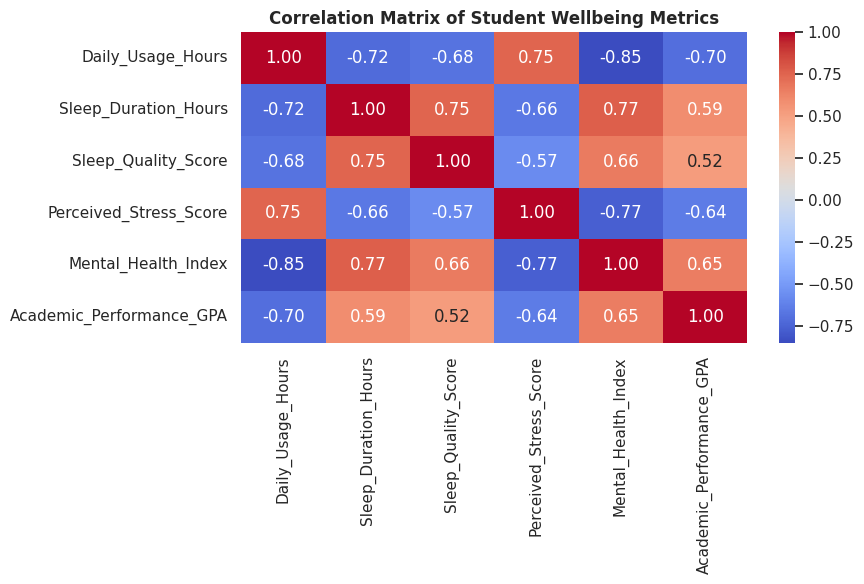

In [17]:
plt.figure(figsize=(9, 6))
numeric_df = df[[
    'Daily_Usage_Hours', 'Sleep_Duration_Hours', 'Sleep_Quality_Score',
    'Perceived_Stress_Score', 'Mental_Health_Index', 'Academic_Performance_GPA'
]]

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Matrix of Student Wellbeing Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

=== MODEL PERFORMANCE EVALUATION ===
Linear Regression:
  - RMSE : 0.2596
  - R² Score: 0.5456

Random Forest Regressor:
  - RMSE : 0.2774
  - R² Score: 0.4810


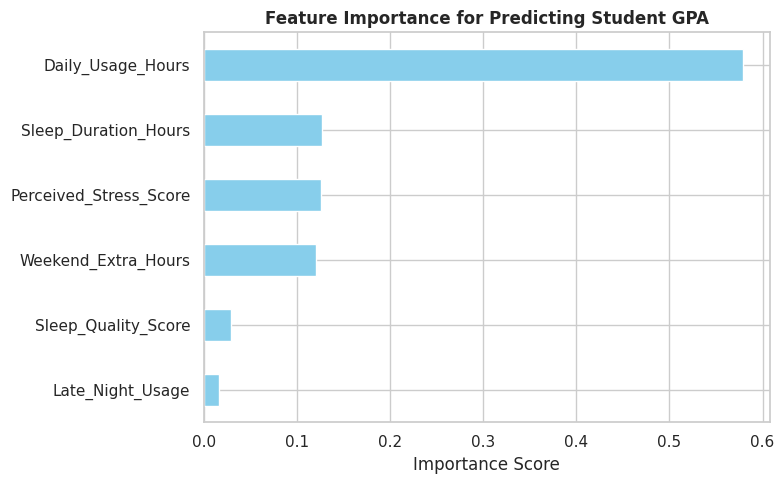

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Feature Selection & Preprocessing
features = ['Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Sleep_Duration_Hours',
            'Sleep_Quality_Score', 'Late_Night_Usage', 'Perceived_Stress_Score']
X = df[features]
y = df['Academic_Performance_GPA']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 4. Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 5. Model Evaluation
print("=== MODEL PERFORMANCE EVALUATION ===")
print("Linear Regression:")
print(f"  - RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"  - R² Score: {r2_score(y_test, y_pred_lr):.4f}")

print("\nRandom Forest Regressor:")
print(f"  - RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")
print(f"  - R² Score: {r2_score(y_test, y_pred_rf):.4f}")

# 6. Plot Feature Importance (Which factors predict GPA best?)
plt.figure(figsize=(8, 5))
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importance for Predicting Student GPA', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import pandas as pd

def predict_student_gpa(daily_hours, weekend_hours, sleep_hours, sleep_quality, late_night, stress_score):
    """
    Predicts a student's Academic GPA based on habit inputs using the trained Linear Regression model.
    """
    # 1. Format input data into DataFrame
    input_data = pd.DataFrame([{
        'Daily_Usage_Hours': daily_hours,
        'Weekend_Extra_Hours': weekend_hours,
        'Sleep_Duration_Hours': sleep_hours,
        'Sleep_Quality_Score': sleep_quality,
        'Late_Night_Usage': bool(late_night),
        'Perceived_Stress_Score': stress_score
    }])

    # 2. Generate GPA Prediction
    predicted_gpa = lr_model.predict(input_data)[0]
    predicted_gpa = np.clip(predicted_gpa, 0.0, 4.0)  # Bound within standard GPA scale

    # 3. Categorize Academic Risk Profile
    if predicted_gpa >= 3.5:
        risk_level = "Low Risk (High Academic Standing)"
    elif predicted_gpa >= 3.0:
        risk_level = "Moderate Risk (Average Performance)"
    else:
        risk_level = "High Academic Risk (Intervention Recommended)"

    print("=" * 50)
    print("             STUDENT GPA PREDICTION SYSTEM          ")
    print("=" * 50)
    print(f"Daily Social Media Usage : {daily_hours} hrs/day")
    print(f"Sleep Duration           : {sleep_hours} hrs/night")
    print(f"Perceived Stress Score   : {stress_score}")
    print("-" * 50)
    print(f"PREDICTED GPA           : {predicted_gpa:.2f} / 4.0")
    print(f"ACADEMIC RISK LEVEL     : {risk_level}")
    print("=" * 50)

# --- TEST CUSTOM PREDICTIONS ---
# Student A: Moderate Usage, Good Sleep
predict_student_gpa(
    daily_hours=2.5,
    weekend_hours=1.0,
    sleep_hours=8.0,
    sleep_quality=4,
    late_night=False,
    stress_score=10.0
)

print("\n")

# Student B: High Usage, Poor Sleep, Late Night Exposure
predict_student_gpa(
    daily_hours=8.5,
    weekend_hours=3.0,
    sleep_hours=5.0,
    sleep_quality=2,
    late_night=True,
    stress_score=22.0
)

             STUDENT GPA PREDICTION SYSTEM          
Daily Social Media Usage : 2.5 hrs/day
Sleep Duration           : 8.0 hrs/night
Perceived Stress Score   : 10.0
--------------------------------------------------
PREDICTED GPA           : 3.70 / 4.0
ACADEMIC RISK LEVEL     : Low Risk (High Academic Standing)


             STUDENT GPA PREDICTION SYSTEM          
Daily Social Media Usage : 8.5 hrs/day
Sleep Duration           : 5.0 hrs/night
Perceived Stress Score   : 22.0
--------------------------------------------------
PREDICTED GPA           : 3.04 / 4.0
ACADEMIC RISK LEVEL     : Moderate Risk (Average Performance)
